Amostra do Dataset de Engenharia:
   Rotacao_RPM   Carga_kg  Consumo_Watts
0  2290.996569  22.652428    1555.631636
1  2426.668967  10.032261    1402.869194
2  1071.185566  31.556449    1164.161617
3  1428.804141   0.889563     710.236928
4  2713.192454  41.927533    2120.094831

Formato da Matriz de Entrada X: (200, 2) (Amostras x Variáveis)
Formato do Vetor de Saída y: (200, 1)


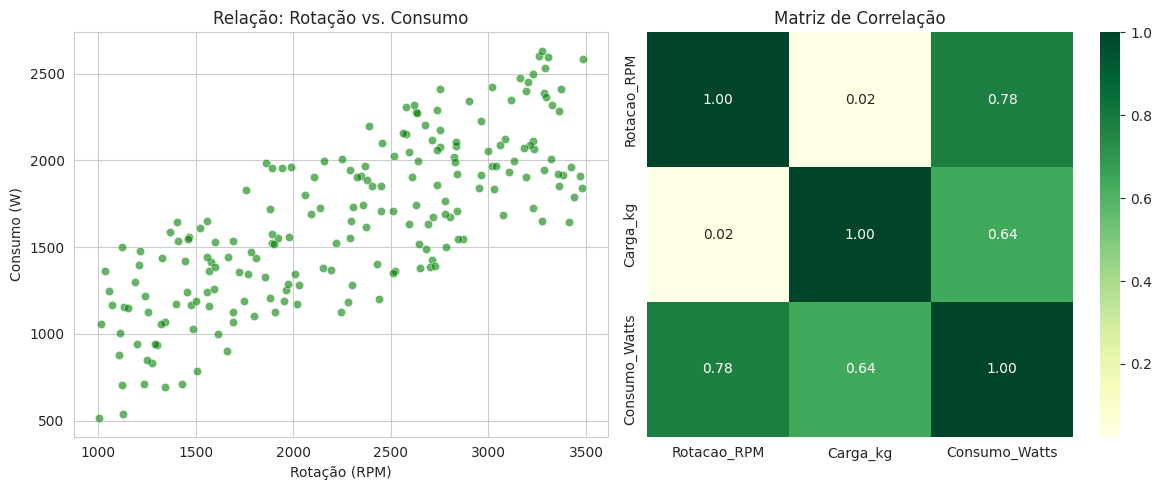

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Geração de Dados (Simulação de Sensores) ---
# Configuração para reprodutibilidade
np.random.seed(101)
n_amostras = 200  # Número de leituras dos sensores

# Variável 1: Rotação do Motor (entre 1000 e 3500 RPM)
rotacao_rpm = np.random.uniform(1000, 3500, n_amostras)

# Variável 2: Carga no Eixo (entre 0 e 50 kg)
carga_kg = np.random.uniform(0, 50, n_amostras)

# Variável Alvo (Target): Consumo de Energia (Watts)
# O consumo aumenta com a rotação e com a carga (simulação física simplificada)
# Fórmula: Consumo = Base + (A * Rotação) + (B * Carga) + Ruído(Erro)
ruido = np.random.normal(0, 50, n_amostras) # Variações aleatórias do processo
consumo_watts = (0.5 * rotacao_rpm) + (20 * carga_kg) + ruido

# --- 2. Estruturação dos Dados (Pandas) ---
# Organizando como se fosse uma tabela de Excel lida pelo Python
dataset_motor = pd.DataFrame({
    'Rotacao_RPM': rotacao_rpm,
    'Carga_kg': carga_kg,
    'Consumo_Watts': consumo_watts
})

# Visualizando as primeiras 5 linhas para o aluno entender a estrutura tabular
print("Amostra do Dataset de Engenharia:")
print(dataset_motor.head())

# --- 3. Álgebra Linear: Conversão para Matrizes (NumPy) ---
# É aqui que preparamos os dados para a Rede Neural.
# X deve ser uma Matriz (n amostras, m features)
X = dataset_motor[['Rotacao_RPM', 'Carga_kg']].values

# y deve ser um Vetor ou Matriz Coluna (n amostras, 1 target)
y = dataset_motor[['Consumo_Watts']].values

print(f"\nFormato da Matriz de Entrada X: {X.shape} (Amostras x Variáveis)")
print(f"Formato do Vetor de Saída y: {y.shape}")

# --- 4. Análise Exploratória ---
# Visualizando a relação entre Rotação e Consumo
plt.figure(figsize=(12, 5))

# Gráfico 1: Dispersão (Scatter Plot)
plt.subplot(1, 2, 1)
sns.scatterplot(x='Rotacao_RPM', y='Consumo_Watts', data=dataset_motor, color='green', alpha=0.6)
plt.title('Relação: Rotação vs. Consumo')
plt.xlabel("Rotação (RPM)")
plt.ylabel("Consumo (W)")
plt.grid(True)

# Gráfico 2: Matriz de Correlação (Heatmap)
# Mostra o quão forte é a relação linear entre as variáveis
plt.subplot(1, 2, 2)
sns.heatmap(dataset_motor.corr(), annot=True, cmap='YlGn', fmt=".2f")
plt.title('Matriz de Correlação')

plt.tight_layout()
plt.show()